In [1]:
import numpy as np

import json
from matplotlib import pyplot as plt 
from pathlib import Path

import pandas as pd

In [2]:
# DATA_DIR = Path("../../tmp/toy-experiments-5k")
DATA_DIR = Path("../../artifacts/2023-05-s6/dev/toy-experiments")

In [3]:
 np.trapz(
#      [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
#      [0,   0.2, 0.4, 0.6, 0.8, 1.0]
     np.array([0, 0.1, 0.2, 0.3, 0.4, 0.5]) + 0.5,
     dx=0.2
 )

0.75

In [12]:
def load_auroc(eps, seeds, subset_slug, basis_name, model="mlp32", layer="act2"):
    
    merged_key = "auroc"
    
    
    merged_stat = dict()
    
    arr_aurocs = []
    arr_area_aurocs = []
    arr_teacher_aurocs = []
    
    for six, seed in enumerate(seeds):
        
        file = DATA_DIR / f"toy-dataset-eps{eps}-seed{seed}" / model / f"subdataset--{subset_slug}" / layer / basis_name / "auroc.json"


        with open(file, "r") as fh:
            _stat = json.load(fh)
                        
        ks = np.array(_stat["ks"])
        if six == 0:
            merged_stat["ks"] = ks
        else:
            assert (merged_stat["ks"] == ks).all()
        
        auroc = np.array(_stat["auroc"])
        auroc = np.where(auroc < 0.5, 1-auroc, auroc)
        
        
        assert ks[0] == 0
        
        # ks = [0, 1, ..., d]
        # auroc: shape = (num ks,)
        area_auroc_varying_k = np.trapz(
            auroc,
            dx=1/ks[-1]
        )
        
        
        arr_aurocs.append(auroc)
        arr_area_aurocs.append(area_auroc_varying_k)
        arr_teacher_aurocs.append(auroc[-1])
        
    # shape: (num_seeds, len(ks))
    arr_aurocs = np.vstack(arr_aurocs)
    
    nseeds = len(seeds)
    assert arr_aurocs.shape[0] ==  nseeds
    
    merged_stat["mean_auroc"] = np.mean(arr_aurocs, axis=0)
    merged_stat["stderr_auroc"] = np.std(arr_aurocs, axis=0) / (nseeds ** 0.5)
    
    
    merged_stat["mean_area_auroc"] = np.mean(arr_area_aurocs, axis=0)
    merged_stat["stderr_area_auroc"] = np.std(arr_area_aurocs, axis=0) / (nseeds ** 0.5)
    
    
    merged_stat['mean_teacher_auroc'] = np.mean(arr_teacher_aurocs)
    merged_stat['std_teacher_auroc'] = np.std(arr_teacher_aurocs) / (nseeds ** 0.5)

    return merged_stat

    
load_auroc(eps=1.0, seeds=range(1, 1+1), subset_slug="2vs3", model="mlp64", basis_name="pca--centered")

{'ks': array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]),
 'mean_auroc': array([0.5       , 0.53086123, 0.5647046 , 0.95382137, 0.95452601,
        0.95907257, 0.95911451, 0.95908935, 0.95932842, 0.95963879,
        0.95972268, 0.95973107, 0.95969332, 0.95968073, 0.95962201,
        0.9596304 , 0.95966396, 0.95977301, 0.95975203, 0.95972687,
        0.95975623, 0.95976042, 0.95975623, 0.95974784, 0.95976042,
        0.95976462, 0.95978559, 0.95978559, 0.95978559, 0.95978559,
        0.95978559, 0.95978559]),
 'stderr_auroc': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'mean_area_auroc': 0.925307078587432,
 'stderr_area_auroc': 0.0,
 'mean_teacher_auroc': 0.9597855880856514,
 'std_teacher_auroc': 0.0}

In [5]:
load_auroc(eps=1.0, seeds=range(1, 6), subset_slug="2vs3", model="mlp64", basis_name="prca-abs--centered")

{'ks': array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]),
 'mean_auroc': array([0.5       , 0.69247964, 0.95119402, 0.95365158, 0.95335458,
        0.95356242, 0.95545085, 0.95606902, 0.95629026, 0.95607222,
        0.95592044, 0.9559358 , 0.95597585, 0.95594868, 0.9559629 ,
        0.95595533, 0.95593235, 0.95598844, 0.95598441, 0.95597815,
        0.95593558, 0.95591384, 0.9559559 , 0.95596887, 0.95590873,
        0.95588739, 0.95591703, 0.95593354, 0.95592522, 0.9558717 ,
        0.95588788, 0.95587062]),
 'stderr_auroc': array([0.        , 0.02966806, 0.00465279, 0.00293871, 0.00364932,
        0.00328559, 0.00259166, 0.00281477, 0.0029094 , 0.00278758,
        0.00273536, 0.00273908, 0.00278713, 0.00279464, 0.00276906,
        0.00276052, 0.00274001, 0.00277045, 0.00276476, 0.00276392,
        0.00280194, 0.00282567, 0.00282817, 0.00282667, 0.00285156,
        0.00285776, 0.00284123, 0.00

In [6]:
load_auroc(eps=1.0, seeds=range(1, 6), subset_slug="2vs3", model="mlp64", basis_name="random3--centered")

{'ks': array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]),
 'mean_auroc': array([0.5       , 0.6280899 , 0.63856122, 0.65578699, 0.71346974,
        0.72053   , 0.77718786, 0.79028064, 0.81104169, 0.87910283,
        0.89740491, 0.87595039, 0.86841218, 0.85685037, 0.85277808,
        0.87497712, 0.92030563, 0.92505931, 0.9272375 , 0.9311324 ,
        0.94633098, 0.94394011, 0.94176978, 0.94776953, 0.94541617,
        0.94843752, 0.94964314, 0.94990772, 0.95230943, 0.9523713 ,
        0.95489585, 0.9550719 ]),
 'stderr_auroc': array([0.        , 0.04357551, 0.03475512, 0.04512299, 0.03472348,
        0.0501339 , 0.05301136, 0.0534687 , 0.04623592, 0.02442721,
        0.0182251 , 0.03301302, 0.0405397 , 0.03640451, 0.03982795,
        0.04790889, 0.01607015, 0.01748222, 0.01082996, 0.01087836,
        0.00412546, 0.00353242, 0.0025262 , 0.00224815, 0.00495076,
        0.00470212, 0.00429869, 0.00

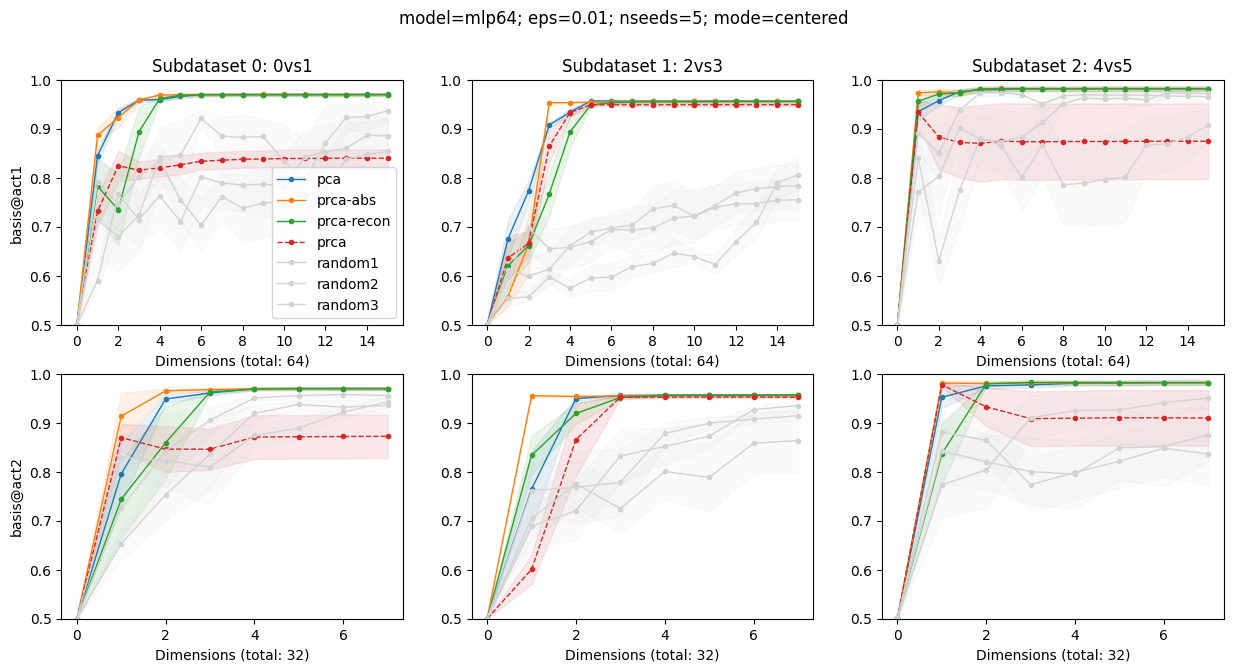

In [24]:
def color(name):
    if "random" in name:
        return "lightgray"
    else:
        return None
def ls(name):
    if "prca" == name:
        return "--"
    else:
        return None
    
def viz_auroc(
    model="mlp64", eps=1.0, 
    seeds=[1, 2], 
    layers=["act1", "act2"],
    basis_names = [
        "pca", "prca-abs", "prca-recon",
        "prca",
        "random1", "random2", "random3",
    ],
    mode="centered"
):
    
    
    nrows = len(layers)
    ncols = 3
    plt.figure(figsize=(ncols*5, nrows*3.5))
    plt.suptitle(f"model={model}; eps={eps}; nseeds={len(seeds)}; mode={mode}")
    
    for lix, layer in enumerate(layers):
        
        
        for pix, slug in enumerate([
            "0vs1",
            "2vs3",
            "4vs5"
        ]):
            plt.subplot(nrows, ncols, lix*ncols + pix + 1)
            
            for basis in basis_names:
                basis_name = f"{basis}--{mode}"
                
                stats = load_auroc(eps=eps, seeds=seeds, subset_slug=slug, model=model, layer=layer, basis_name=basis_name)
                
                dims = len(stats['ks'])
                top_k = dims // 4
                ks = stats['ks'][:top_k]
                mean = stats['mean_auroc'][:top_k]
                std = stats['stderr_auroc'][:top_k] 
                plt.plot(
                    ks, mean, 
                    label=basis, 
                    lw=1,
                    color=color(basis),
                    ls=ls(basis),
                    marker="."
                )
                
                plt.fill_between(
                    ks,
                    mean - std,
                    mean + std, 
                    alpha=0.1,
                    color=plt.gca().lines[-1].get_color()
                )
                
            plt.xlabel(f"Dimensions (total: {dims})")
            plt.xticks(ks[::2])
            plt.ylim([0.5, 1])
            if pix == 0:
                plt.ylabel(f"basis@{layer}")

            if lix == 0:
                plt.title(f"Subdataset {pix}: {slug}")
                
            if lix == 0 and pix == 0:
                plt.legend()
viz_auroc(seeds=[1, 2, 3, 4, 5], eps=0.01)

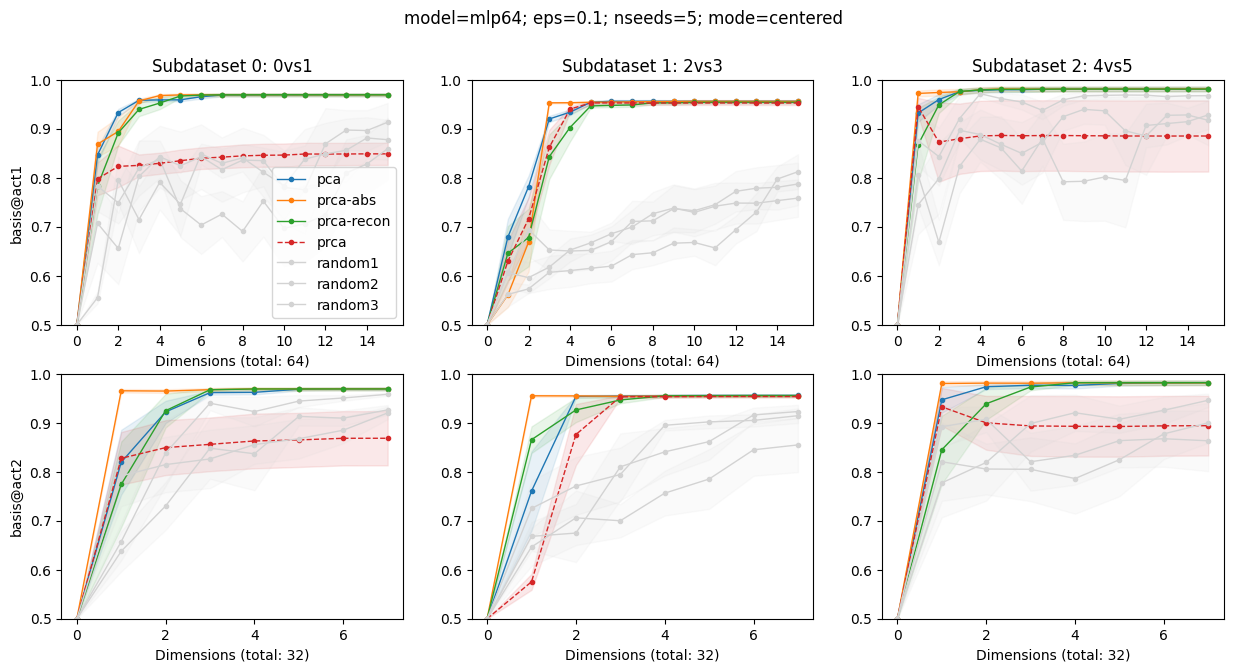

In [25]:
viz_auroc(seeds=[1, 2, 3, 4, 5], eps=0.1)

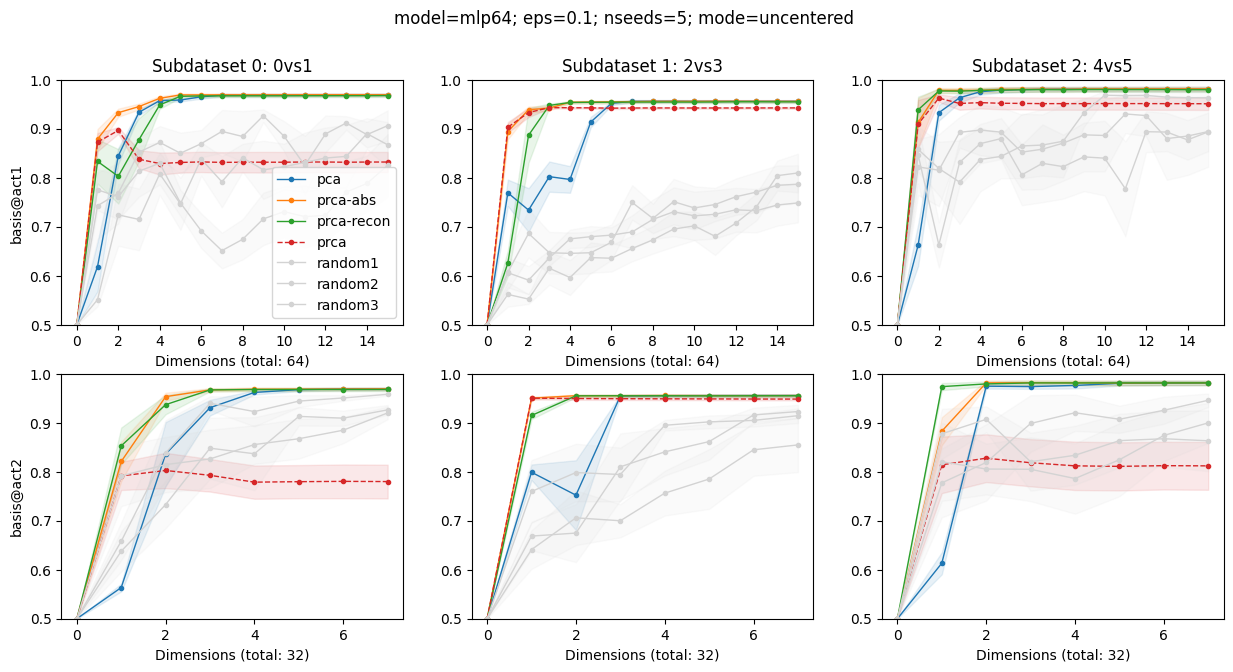

In [26]:
viz_auroc(seeds=[1, 2, 3, 4, 5], eps=0.1, mode="uncentered")

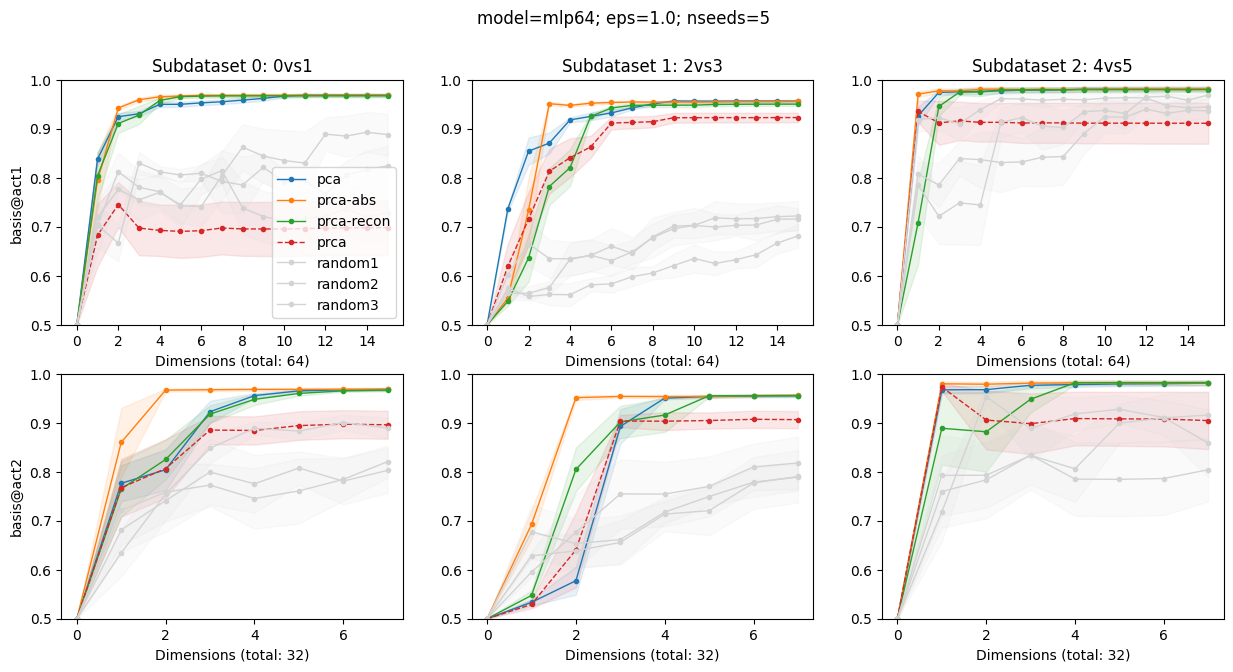

In [9]:
viz_auroc(seeds=[1, 2, 3, 4, 5], eps=1.0)

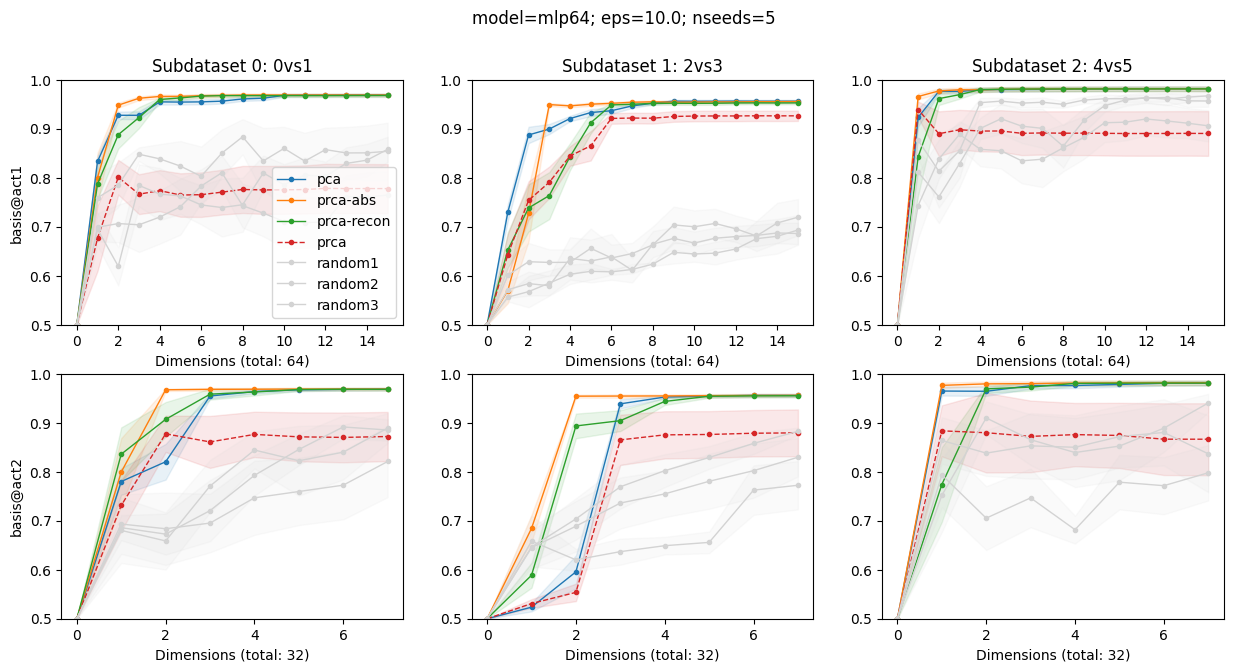

In [10]:
viz_auroc(seeds=[1, 2, 3, 4, 5], eps=10.0)

# Vis Table

In [20]:
def table(model, eps, mode="centered"):
    arr_layers = ["act1", "act2"]
    arr_groups = ["0vs1", "2vs3", "4vs5"]
    seeds = list(range(1, 5+1))
    arr_bases = [
        "random1", 
#         "random2", "random3",
        "pca", 
        "prca-abs", "prca-recon", "prca",
    ]
    
    
    arr_rows = []
    
    print(f"                 model={model}; eps={eps}; mode={mode}")
    
    for lix, layer in enumerate(arr_layers):
        
        for basis in arr_bases:
            
            row = dict(layer=layer, basis=basis)
        
        
            for slug in arr_groups:
                data = load_auroc(
                    eps=eps,
                    seeds=seeds,
                    subset_slug=slug,
                    model=model,
                    layer=layer,
                    basis_name=f"{basis}--{mode}"
                )
                
                
                
                row[slug] = "%.4f±%.4f" % (data["mean_area_auroc"], data["stderr_area_auroc"])
        
            arr_rows.append(row)
        
    
    return pd.DataFrame(arr_rows)

        
table(model="mlp16", eps=0.01)

                 model=mlp16; eps=0.01; mode=centered


,layer,basis,0vs1,2vs3,4vs5
0,act1,random1,0.8924±0.0184,0.7434±0.0091,0.8476±0.0375
1,act1,pca,0.9396±0.0040,0.9067±0.0041,0.9608±0.0048
2,act1,prca-abs,0.9406±0.0032,0.8919±0.0045,0.9606±0.0046
3,act1,prca-recon,0.9354±0.0058,0.8842±0.0034,0.9584±0.0032
4,act1,prca,0.7622±0.0561,0.8206±0.0268,0.8922±0.0391
5,act2,random1,0.8740±0.0220,0.8275±0.0356,0.8977±0.0172
6,act2,pca,0.9152±0.0060,0.8482±0.0116,0.9413±0.0049
7,act2,prca-abs,0.9305±0.0041,0.9000±0.0075,0.9444±0.0043
8,act2,prca-recon,0.9068±0.0109,0.8850±0.0141,0.9439±0.0045
9,act2,prca,0.8616±0.0238,0.7431±0.0542,0.7935±0.0548


In [21]:
table(model="mlp64", eps=0.1, mode="centered")

                 model=mlp64; eps=0.1; mode=centered


,layer,basis,0vs1,2vs3,4vs5
0,act1,random1,0.9115±0.0209,0.8684±0.0100,0.9362±0.0093
1,act1,pca,0.9624±0.0029,0.9442±0.0022,0.9762±0.0047
2,act1,prca-abs,0.9625±0.0032,0.9413±0.0027,0.9771±0.0047
3,act1,prca-recon,0.9606±0.0037,0.9392±0.0031,0.9749±0.0047
4,act1,prca,0.8461±0.0217,0.9386±0.0052,0.8828±0.0713
5,act2,random1,0.9246±0.0095,0.9073±0.0106,0.9399±0.0141
6,act2,pca,0.9548±0.0043,0.9421±0.0016,0.9719±0.0045
7,act2,prca-abs,0.9613±0.0029,0.9483±0.0024,0.9735±0.0046
8,act2,prca-recon,0.9537±0.0055,0.9442±0.0016,0.9677±0.0042
9,act2,prca,0.8609±0.0544,0.9315±0.0021,0.8889±0.0593


In [22]:
table(model="mlp64", eps=0.1, mode="uncentered")

                 model=mlp64; eps=0.1; mode=uncentered


,layer,basis,0vs1,2vs3,4vs5
0,act1,random1,0.9228±0.0133,0.8642±0.0108,0.9309±0.0146
1,act1,pca,0.9569±0.0031,0.9401±0.0016,0.9712±0.0048
2,act1,prca-abs,0.9630±0.0031,0.9507±0.0022,0.9762±0.0045
3,act1,prca-recon,0.9581±0.0041,0.9451±0.0028,0.9758±0.0043
4,act1,prca,0.8305±0.0199,0.9381±0.0017,0.9474±0.0118
5,act2,random1,0.9246±0.0095,0.9073±0.0106,0.9395±0.0141
6,act2,pca,0.9427±0.0043,0.9368±0.0017,0.9611±0.0047
7,act2,prca-abs,0.9562±0.0039,0.9483±0.0024,0.9704±0.0050
8,act2,prca-recon,0.9560±0.0043,0.9469±0.0023,0.9734±0.0046
9,act2,prca,0.7770±0.0335,0.9410±0.0025,0.8084±0.0481
